<a href="https://colab.research.google.com/github/epkalibbala/quant-finance-research-lab/blob/main/Financial_Volatility_Modelling_Using_GARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install Required Library
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 17.2 MB/s eta 0:00:00


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from arch import arch_model

In [4]:
# Download Financial Data
data = yf.download("SPY", start="2018-01-01", end="2024-01-01")

/tmp/ipykernel_432/3863096019.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [6]:
# Compute Log Returns
returns = np.log(data["Close"]).diff().dropna()

returns = returns * 100

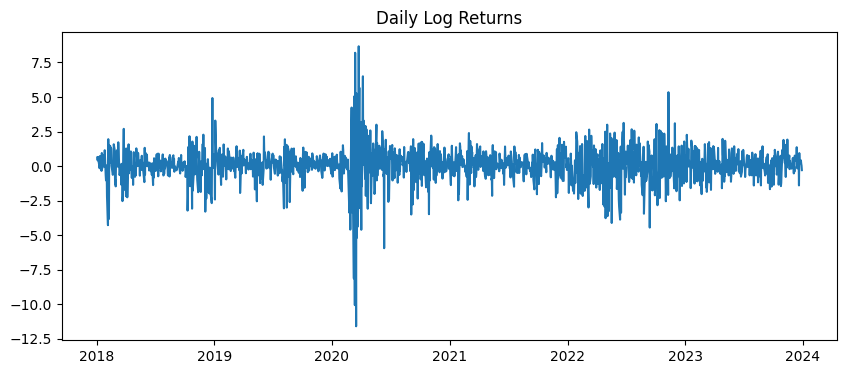

In [7]:
# Visualize Returns - volatility clustering.
plt.figure(figsize=(10,4))

plt.plot(returns)

plt.title("Daily Log Returns")

plt.show()

In [8]:
# Fit GARCH(1,1)
model = arch_model(

    returns,
    vol="Garch",
    p=1,
    q=1
)

results = model.fit()

print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 12338.337916770812
Iteration:      2,   Func. Count:     16,   Neg. LLF: 8877.042195993952
Iteration:      3,   Func. Count:     25,   Neg. LLF: 3214.2288380677683
Iteration:      4,   Func. Count:     32,   Neg. LLF: 2168.6242789632797
Iteration:      5,   Func. Count:     38,   Neg. LLF: 817200023.0164617
Iteration:      6,   Func. Count:     45,   Neg. LLF: 2141.448461811008
Iteration:      7,   Func. Count:     50,   Neg. LLF: 2141.424524524875
Iteration:      8,   Func. Count:     55,   Neg. LLF: 2141.4239169858783
Iteration:      9,   Func. Count:     60,   Neg. LLF: 2141.423915047231
Iteration:     10,   Func. Count:     64,   Neg. LLF: 2141.4239150476697
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2141.423915047231
            Iterations: 10
            Function evaluations: 64
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results          

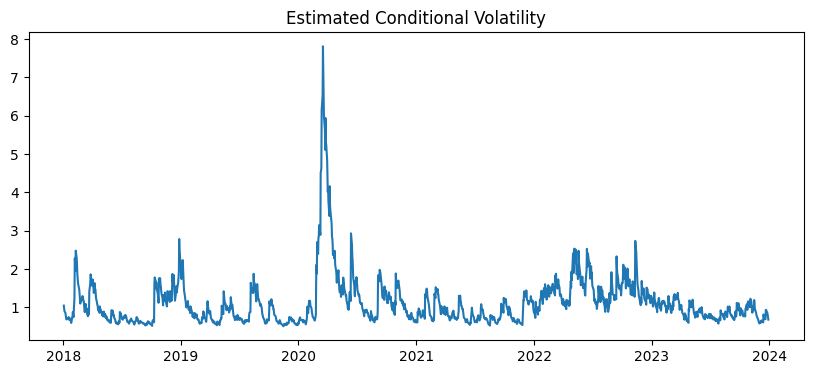

In [9]:
# Plot Conditional Volatility - shows how risk changes over time
volatility = results.conditional_volatility

plt.figure(figsize=(10,4))

plt.plot(volatility)

plt.title("Estimated Conditional Volatility")

plt.show()

In [10]:
# Forecast Future Volatility
forecast = results.forecast(horizon=5)

print(forecast.variance.tail())

                 h.1       h.2       h.3       h.4       h.5
Date                                                        
2023-12-29  0.434339  0.472856  0.510477  0.547223  0.583114


In [11]:
# Value at Risk (VaR)
from scipy.stats import norm

z = norm.ppf(0.01)

var = z * volatility.iloc[-1]

print("1% VaR:",var)

1% VaR: -1.5771136563890737
